In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

customers = pd.read_csv("customers.csv")
orders = pd.read_csv("orders.csv")
deliveries = pd.read_csv("deliveries.csv")
drivers = pd.read_csv("drivers.csv")
vehicles = pd.read_csv("vehicles.csv")
hubs = pd.read_csv("hubs.csv")
complaints = pd.read_csv("complaints.csv")
incidents = pd.read_csv("incidents.csv")
app_events = pd.read_csv("app_events.csv")
data_dictionary = pd.read_csv("data_dictionary.csv")

print("All datasets loaded successfully")

print(customers.shape)
print(orders.shape)
print(deliveries.shape)

All datasets loaded successfully
(650, 9)
(1250, 11)
(950, 13)


In [2]:
# Check missing values

print(customers.isnull().sum())

print("\n-----------------\n")

print(orders.isnull().sum())

print("\n-----------------\n")

print(deliveries.isnull().sum())

customer_id              0
age                      0
home_zone                0
customer_type            0
signup_date              0
loyalty_score           20
app_engagement_score     0
preferred_channel       13
account_status           0
dtype: int64

-----------------

order_id                  0
customer_id               0
service_type              0
order_created_at          0
promised_window_hours     0
pickup_zone               0
dropoff_zone              0
priority_level            0
order_value               0
booking_channel          25
special_handling_flag     0
dtype: int64

-----------------

delivery_id                       0
order_id                          0
driver_id                         0
vehicle_id                        0
hub_id                            0
dispatch_time                     0
delivery_completed_at            19
delivery_status                   0
route_distance_km                 0
manual_route_override_count       0
proof_of_completion_mis

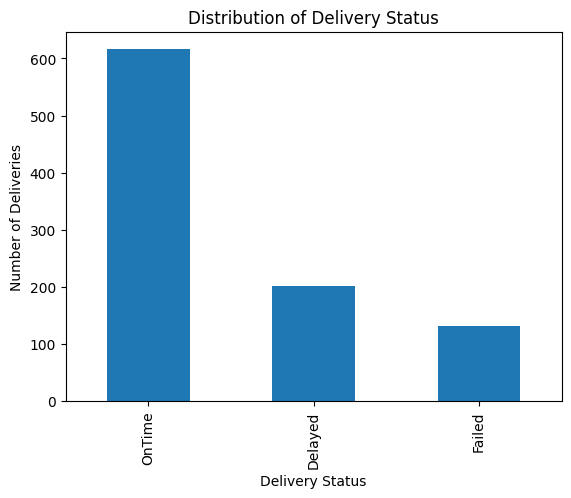

In [3]:
# Delivery status distribution

delivery_counts = deliveries["delivery_status"].value_counts()

delivery_counts.plot(kind="bar")

plt.title("Distribution of Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Deliveries")

plt.show()

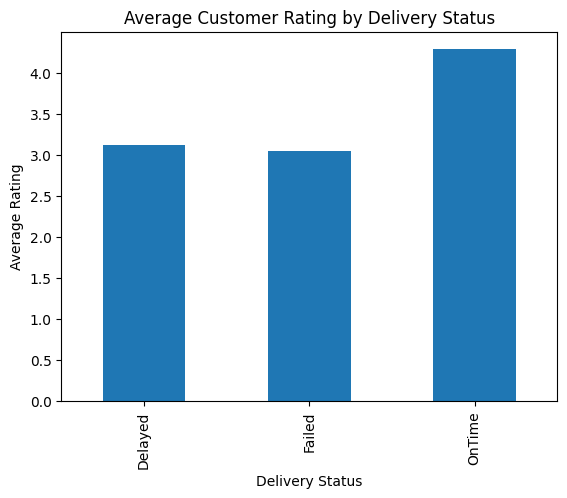

In [4]:
# Customer rating by delivery status

average_rating = deliveries.groupby(
    "delivery_status"
)["customer_rating_post_delivery"].mean()

average_rating.plot(kind="bar")

plt.title("Average Customer Rating by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Average Rating")

plt.show()

In [5]:
!pip install pymongo dnspython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 21.1 MB/s eta 0:00:00


In [6]:
from pymongo import MongoClient
import pandas as pd

In [7]:
# Simulated MongoDB document structure

delivery_document = {

"delivery_id":"D001",
"customer_id":"C001",
"delivery_status":"OnTime",
"route_distance_km":12.5,
"manual_route_override_count":1,
"customer_rating_post_delivery":4.5,
"fuel_or_charge_cost":10.8

}

print(delivery_document)

{'delivery_id': 'D001', 'customer_id': 'C001', 'delivery_status': 'OnTime', 'route_distance_km': 12.5, 'manual_route_override_count': 1, 'customer_rating_post_delivery': 4.5, 'fuel_or_charge_cost': 10.8}


In [8]:
!pip install mongomock

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 2.6 MB/s eta 0:00:00


In [9]:
import mongomock

client = mongomock.MongoClient()
db = client["northstar_database"]
deliveries_collection = db["deliveries"]

print("MongoDB-style database created successfully")

MongoDB-style database created successfully


In [11]:
# CREATE operation

delivery_document = {
    "delivery_id": "D001",
    "customer_id": "C001",
    "delivery_status": "OnTime",
    "route_distance_km": 12.5,
    "manual_route_override_count": 1,
    "customer_rating_post_delivery": 4.5,
    "fuel_or_charge_cost": 10.8
}

deliveries_collection.insert_one(delivery_document)

print("Document inserted successfully")

Document inserted successfully


In [12]:
# READ operation

result = deliveries_collection.find_one(
    {"delivery_id":"D001"}
)

print(result)

{'delivery_id': 'D001', 'customer_id': 'C001', 'delivery_status': 'OnTime', 'route_distance_km': 12.5, 'manual_route_override_count': 1, 'customer_rating_post_delivery': 4.5, 'fuel_or_charge_cost': 10.8, '_id': ObjectId('6a1331f86fda0d005d12a74f')}


In [13]:
# UPDATE operation

deliveries_collection.update_one(
    {"delivery_id":"D001"},
    {"$set":{"delivery_status":"Delayed"}}
)

updated_result = deliveries_collection.find_one(
    {"delivery_id":"D001"}
)

print(updated_result)

{'delivery_id': 'D001', 'customer_id': 'C001', 'delivery_status': 'Delayed', 'route_distance_km': 12.5, 'manual_route_override_count': 1, 'customer_rating_post_delivery': 4.5, 'fuel_or_charge_cost': 10.8, '_id': ObjectId('6a1331f86fda0d005d12a74f')}


In [15]:
# DELETE operation

delete_result = deliveries_collection.delete_one(
    {"delivery_id":"D001"}
)

print("Deleted count:", delete_result.deleted_count)

print(deliveries_collection.find_one(
    {"delivery_id":"D001"}
))

Deleted count: 1
None


In [16]:
# Insert multiple documents for optimisation example

sample_deliveries = [
    {"delivery_id": "D002", "delivery_status": "OnTime", "customer_rating": 4.6},
    {"delivery_id": "D003", "delivery_status": "Delayed", "customer_rating": 3.2},
    {"delivery_id": "D004", "delivery_status": "Failed", "customer_rating": 2.9},
    {"delivery_id": "D005", "delivery_status": "OnTime", "customer_rating": 4.8},
    {"delivery_id": "D006", "delivery_status": "Delayed", "customer_rating": 3.4}
]

deliveries_collection.insert_many(sample_deliveries)

print("Sample documents inserted successfully")

Sample documents inserted successfully


In [17]:
# Create index for query optimisation

deliveries_collection.create_index("delivery_status")

print("Index created on delivery_status")

Index created on delivery_status


In [18]:
# Query using indexed field

optimised_query = deliveries_collection.find(
    {"delivery_status": "Delayed"}
)

for document in optimised_query:
    print(document)

{'delivery_id': 'D003', 'delivery_status': 'Delayed', 'customer_rating': 3.2, '_id': ObjectId('6a133a376fda0d005d12a752')}
{'delivery_id': 'D006', 'delivery_status': 'Delayed', 'customer_rating': 3.4, '_id': ObjectId('6a133a376fda0d005d12a755')}
